In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:

data = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/Data_Collection_03_04_2025/raw_data.csv")


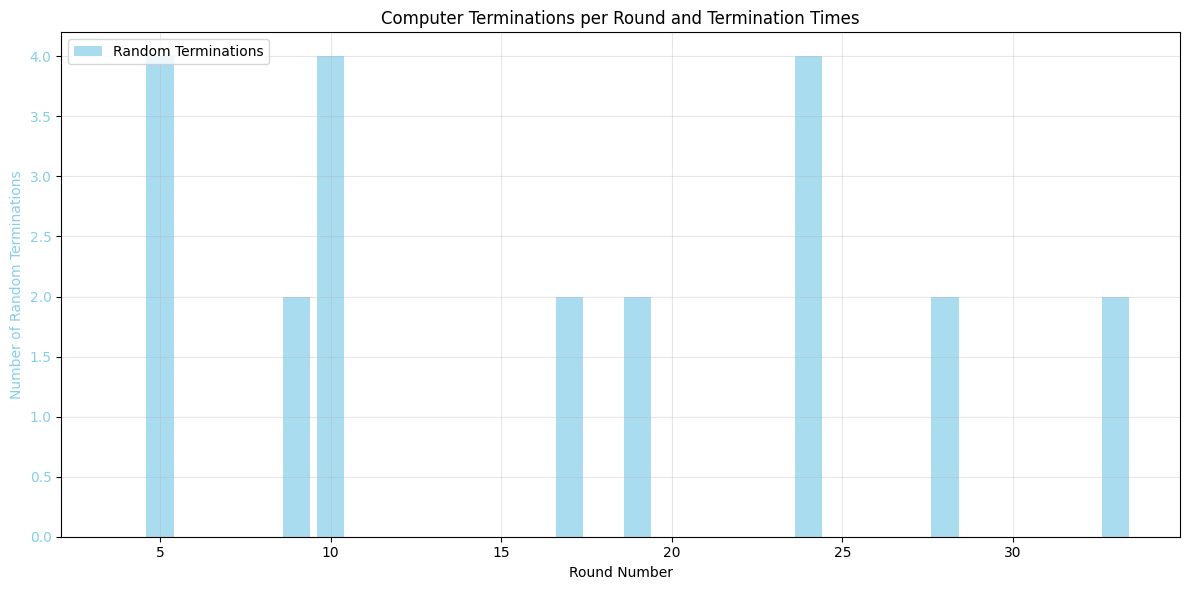

In [3]:
# Create lists to store counts
random_terminations = []
rounds = []

# Count random terminations for each round
for i in range(4, 34):
    counts = data[f'bargain_live.{i}.group.termination_mode'].value_counts()
    if 'Random_Termination' in counts:
        random_terminations.append(counts['Random_Termination'] / 2) 
    else:
        random_terminations.append(0)
    rounds.append(i)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot random terminations on primary axis
ax1.bar(rounds, random_terminations, color='skyblue', alpha=0.7)
ax1.set_xlabel('Round Number')
ax1.set_ylabel('Number of Random Terminations', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')



plt.title('Computer Terminations per Round and Termination Times')
plt.grid(True, alpha=0.3)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(['Random Terminations'], loc='upper left')

plt.tight_layout()
plt.show()

## Payoffs

In [4]:
payoff_df = pd.DataFrame()
for i in range(4, 34):
    payoff_df[f'{i - 3}'] = data[f'bargain_live.{i}.player.payoff']


Text(0.5, 1.0, 'Payoffs with Outliers')

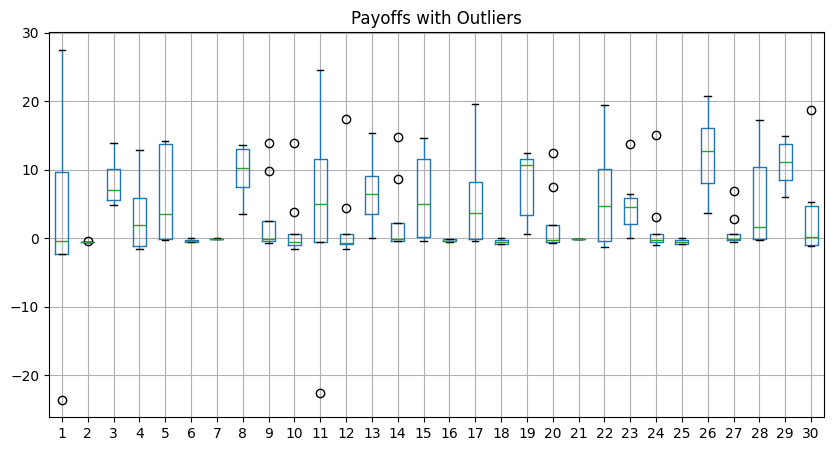

In [5]:
payoff_df.boxplot(figsize=(10,5))
plt.title('Payoffs with Outliers')



Text(0.5, 1.0, 'Payoffs without Outliers')

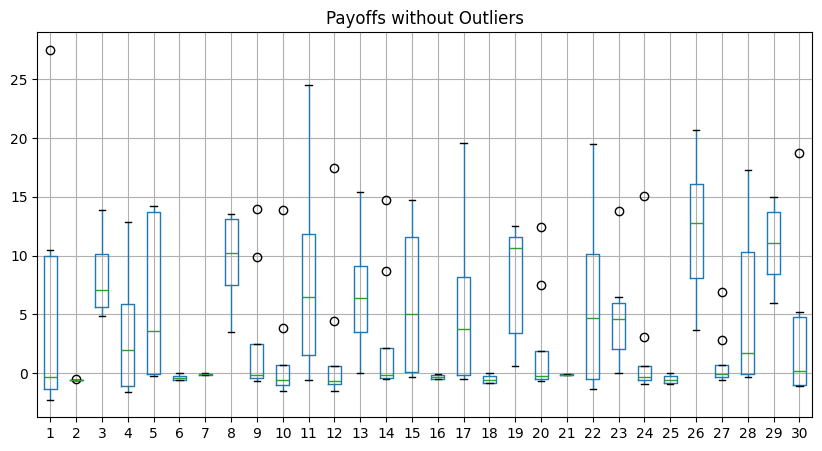

In [6]:
payoff_df[payoff_df < -10] = np.nan
payoff_df.boxplot(figsize=(10,5))
plt.title('Payoffs without Outliers')



In [7]:
# Cost Estimation
payoff_df[payoff_df < 7.5] = 7.5
mean_payoff_per_column = payoff_df.mean()
mean_payoff_per_column

1     11.064286
2      7.500000
3      9.181250
4      8.175000
5      9.906250
6      7.500000
7      7.500000
8     10.437500
9      8.600000
10     8.300000
11    11.157143
12     8.743750
13     9.156250
14     8.556250
15     9.443750
16     7.500000
17     9.231250
18     7.500000
19     9.943750
20     8.112500
21     7.500000
22     9.975000
23     8.287500
24     8.450000
25     7.500000
26    12.743750
27     7.500000
28     9.431250
29    11.118750
30     8.900000
dtype: float64

np.float64(13.84375)

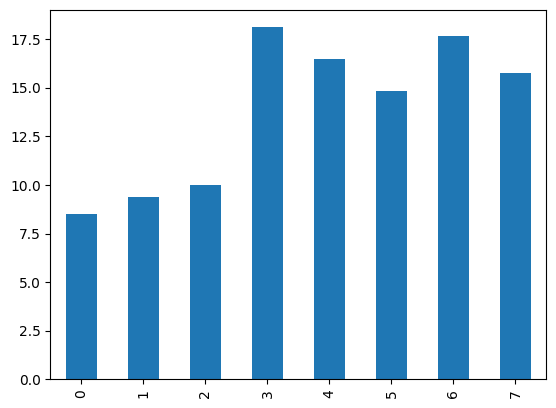

In [8]:
#Final Paoffs this roudn
data['participant.payoff'].plot(kind='bar')
data["participant.payoff"].mean()

## Realized Gains from Trade

In [9]:
# Assume df is your DataFrame with 8 rows (one per player)
# and the necessary columns for rounds 4 to 33.

# List the rounds
round_num = 6

# Dictionary to store gains for each round
gains_df = pd.DataFrame()

valuation_col = f"bargain_live.{round_num}.player.valuation"
deal_price_col = f"bargain_live.{round_num}.group.deal_price"

# Calculate gains based on the player's role:
# If Buyer: gain = valuation - deal_price
# Else (Seller): gain = deal_price - valuation
gains_df[f"Round {round_num - 3}"] = np.where(
    data[f"bargain_live.{round_num}.player.role"] == "Buyer",
    data[valuation_col] - data[deal_price_col],
    data[deal_price_col] - data[valuation_col]
)

gains_df["Valuation"] = data[f"bargain_live.{round_num}.player.valuation"]
gains_df["Deal Price"] = data[f"bargain_live.{round_num}.group.deal_price"]
gains_df["Role"] = data[f"bargain_live.{round_num}.player.role"]


In [10]:
gains_df

,Round 3,Valuation,Deal Price,Role
0,7.0,0.0,7.0,Seller
1,6.0,13.0,7.0,Buyer
2,14.0,0.0,14.0,Seller
3,15.0,29.0,14.0,Buyer
4,10.0,18.0,8.0,Buyer
5,8.0,0.0,8.0,Seller
6,8.0,0.0,8.0,Seller
7,10.0,18.0,8.0,Buyer


In [11]:
# Assume df is your DataFrame with 8 rows (one per player)
# and the necessary columns for rounds 4 to 33.

# List the rounds
rounds = range(4, 34)  # rounds 4 to 33 inclusive

# Dictionary to store gains for each round
gains_df = pd.DataFrame()

# Loop over each round and compute gains from trade
for round_num in rounds:
    valuation_col = f"bargain_live.{round_num}.player.valuation"
    deal_price_col = f"bargain_live.{round_num}.group.deal_price"
    
    # Calculate gains based on the player's role:
    # If Buyer: gain = valuation - deal_price
    # Else (Seller): gain = deal_price - valuation
    gains_df[f"Round {round_num - 3}"] = np.where(
    data[f"bargain_live.{round_num}.player.role"] == "Buyer",
    data[valuation_col] - data[deal_price_col],
    data[deal_price_col] - data[valuation_col]
)


In [12]:
gains_df

,Round 1,Round 2,Round 3,Round 4,Round 5,Round 6,Round 7,Round 8,Round 9,Round 10,...,Round 21,Round 22,Round 23,Round 24,Round 25,Round 26,Round 27,Round 28,Round 29,Round 30
0,28.0,NaN,7.0,NaN,NaN,NaN,NaN,14.0,NaN,16.0,...,NaN,NaN,15.0,NaN,NaN,13.0,NaN,NaN,15.0,NaN
1,NaN,NaN,6.0,NaN,NaN,NaN,NaN,11.0,14.0,6.0,...,NaN,20.0,4.0,16.0,NaN,21.0,8.0,18.0,14.0,19.0
2,NaN,NaN,14.0,NaN,14.0,NaN,NaN,12.0,NaN,NaN,...,NaN,11.0,5.0,NaN,NaN,14.0,NaN,11.0,7.0,6.0
3,NaN,NaN,15.0,NaN,NaN,NaN,NaN,9.0,NaN,NaN,...,NaN,10.0,NaN,NaN,NaN,16.0,NaN,NaN,15.0,NaN
4,-23.0,NaN,10.0,15.0,17.0,NaN,NaN,14.0,NaN,NaN,...,NaN,NaN,7.0,NaN,NaN,9.0,NaN,NaN,7.0,NaN
5,NaN,NaN,8.0,7.0,10.0,NaN,NaN,15.0,NaN,NaN,...,NaN,NaN,6.0,NaN,NaN,17.0,NaN,11.0,10.0,NaN
6,11.0,NaN,8.0,8.0,NaN,NaN,NaN,4.0,10.0,NaN,...,NaN,10.0,NaN,4.0,NaN,4.0,4.0,NaN,13.0,5.0
7,10.0,NaN,10.0,6.0,14.0,NaN,NaN,7.0,NaN,NaN,...,NaN,NaN,7.0,NaN,NaN,9.0,NaN,4.0,10.0,2.0


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]),
 [Text(1, 0, 'Round 1'),
  Text(2, 0, 'Round 2'),
  Text(3, 0, 'Round 3'),
  Text(4, 0, 'Round 4'),
  Text(5, 0, 'Round 5'),
  Text(6, 0, 'Round 6'),
  Text(7, 0, 'Round 7'),
  Text(8, 0, 'Round 8'),
  Text(9, 0, 'Round 9'),
  Text(10, 0, 'Round 10'),
  Text(11, 0, 'Round 11'),
  Text(12, 0, 'Round 12'),
  Text(13, 0, 'Round 13'),
  Text(14, 0, 'Round 14'),
  Text(15, 0, 'Round 15'),
  Text(16, 0, 'Round 16'),
  Text(17, 0, 'Round 17'),
  Text(18, 0, 'Round 18'),
  Text(19, 0, 'Round 19'),
  Text(20, 0, 'Round 20'),
  Text(21, 0, 'Round 21'),
  Text(22, 0, 'Round 22'),
  Text(23, 0, 'Round 23'),
  Text(24, 0, 'Round 24'),
  Text(25, 0, 'Round 25'),
  Text(26, 0, 'Round 26'),
  Text(27, 0, 'Round 27'),
  Text(28, 0, 'Round 28'),
  Text(29, 0, 'Round 29'),
  Text(30, 0, 'Round 30')])

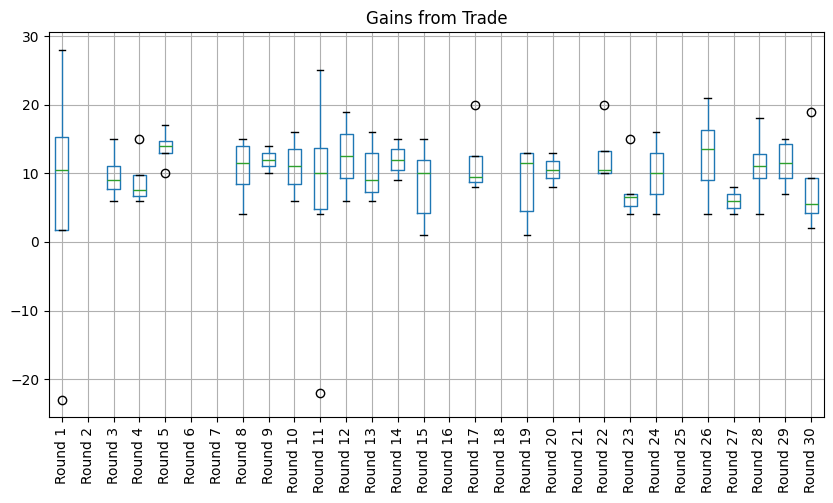

In [13]:
gains_df.boxplot(figsize=(10,5))
plt.title('Gains from Trade')
plt.xticks(rotation=90)

## Gains from Trade as percentage for buyers

In [14]:
# Assume df is your DataFrame with 8 rows (one per player)
# and the necessary columns for rounds 4 to 33.

# List the rounds
rounds = range(4, 34)  # rounds 4 to 33 inclusive

# Dictionary to store gains for each round
gains_seller_percentage_df = pd.DataFrame()

round_num = 6
valuation_col = f"bargain_live.{round_num}.player.valuation"
deal_price_col = f"bargain_live.{round_num}.group.deal_price"


for round_num in rounds:
    valuation_col = f"bargain_live.{round_num}.player.valuation"
    deal_price_col = f"bargain_live.{round_num}.group.deal_price"
    
    # Calculate gains based on the player's role:
    # If Buyer: gain = valuation - deal_price
    # Else (Seller): gain = deal_price - valuation
    gains_seller_percentage_df[f"Round {round_num - 3}"] = np.where(
    (data[f"bargain_live.{round_num}.player.role"] == "Buyer"),
    (data[deal_price_col] / data[valuation_col]),
    np.nan
    
)
    
gains_seller_percentage_df




,Round 1,Round 2,Round 3,Round 4,Round 5,Round 6,Round 7,Round 8,Round 9,Round 10,...,Round 21,Round 22,Round 23,Round 24,Round 25,Round 26,Round 27,Round 28,Round 29,Round 30
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,0.538462,NaN,NaN,NaN,NaN,0.576923,0.416667,0.727273,...,NaN,0.333333,0.600000,0.2,NaN,0.160000,0.333333,0.379310,0.333333,0.208333
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,0.482759,NaN,NaN,NaN,NaN,0.571429,NaN,NaN,...,NaN,0.523810,NaN,NaN,NaN,0.466667,NaN,NaN,0.464286,NaN
4,5.60000,NaN,0.444444,0.318182,0.37037,NaN,NaN,0.222222,NaN,NaN,...,NaN,NaN,0.416667,NaN,NaN,0.590909,NaN,NaN,0.588235,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.52381,NaN,0.444444,0.571429,0.50000,NaN,NaN,0.666667,NaN,NaN,...,NaN,NaN,0.681818,NaN,NaN,0.653846,NaN,0.733333,0.600000,0.750000


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]),
 [Text(1, 0, 'Round 1'),
  Text(2, 0, 'Round 2'),
  Text(3, 0, 'Round 3'),
  Text(4, 0, 'Round 4'),
  Text(5, 0, 'Round 5'),
  Text(6, 0, 'Round 6'),
  Text(7, 0, 'Round 7'),
  Text(8, 0, 'Round 8'),
  Text(9, 0, 'Round 9'),
  Text(10, 0, 'Round 10'),
  Text(11, 0, 'Round 11'),
  Text(12, 0, 'Round 12'),
  Text(13, 0, 'Round 13'),
  Text(14, 0, 'Round 14'),
  Text(15, 0, 'Round 15'),
  Text(16, 0, 'Round 16'),
  Text(17, 0, 'Round 17'),
  Text(18, 0, 'Round 18'),
  Text(19, 0, 'Round 19'),
  Text(20, 0, 'Round 20'),
  Text(21, 0, 'Round 21'),
  Text(22, 0, 'Round 22'),
  Text(23, 0, 'Round 23'),
  Text(24, 0, 'Round 24'),
  Text(25, 0, 'Round 25'),
  Text(26, 0, 'Round 26'),
  Text(27, 0, 'Round 27'),
  Text(28, 0, 'Round 28'),
  Text(29, 0, 'Round 29'),
  Text(30, 0, 'Round 30')])

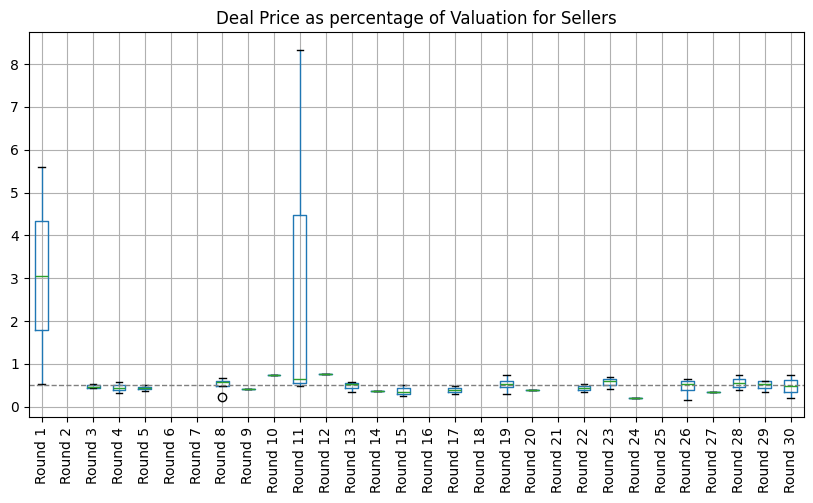

In [15]:
gains_seller_percentage_df.boxplot(figsize=(10,5))
plt.title('Deal Price as percentage of Valuation for Sellers')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
plt.xticks(rotation=90)



In [16]:
gains_seller_percentage_df[gains_seller_percentage_df > 1.1] = np.nan

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]),
 [Text(1, 0, 'Round 1'),
  Text(2, 0, 'Round 2'),
  Text(3, 0, 'Round 3'),
  Text(4, 0, 'Round 4'),
  Text(5, 0, 'Round 5'),
  Text(6, 0, 'Round 6'),
  Text(7, 0, 'Round 7'),
  Text(8, 0, 'Round 8'),
  Text(9, 0, 'Round 9'),
  Text(10, 0, 'Round 10'),
  Text(11, 0, 'Round 11'),
  Text(12, 0, 'Round 12'),
  Text(13, 0, 'Round 13'),
  Text(14, 0, 'Round 14'),
  Text(15, 0, 'Round 15'),
  Text(16, 0, 'Round 16'),
  Text(17, 0, 'Round 17'),
  Text(18, 0, 'Round 18'),
  Text(19, 0, 'Round 19'),
  Text(20, 0, 'Round 20'),
  Text(21, 0, 'Round 21'),
  Text(22, 0, 'Round 22'),
  Text(23, 0, 'Round 23'),
  Text(24, 0, 'Round 24'),
  Text(25, 0, 'Round 25'),
  Text(26, 0, 'Round 26'),
  Text(27, 0, 'Round 27'),
  Text(28, 0, 'Round 28'),
  Text(29, 0, 'Round 29'),
  Text(30, 0, 'Round 30')])

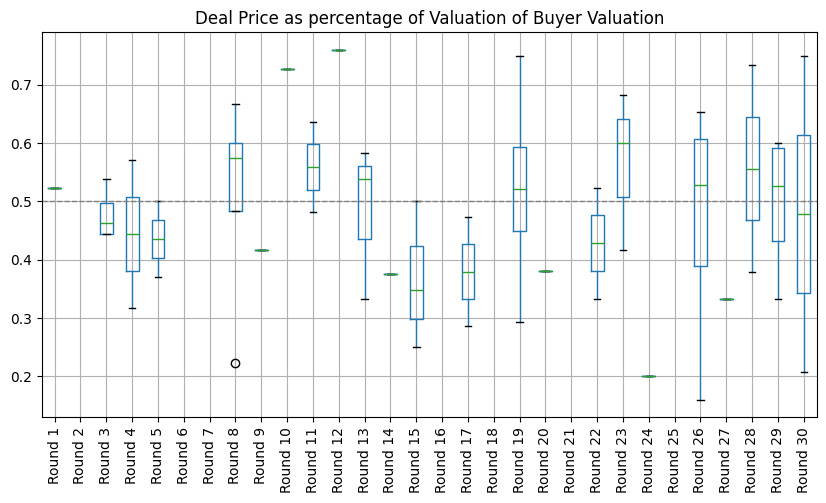

In [17]:
gains_seller_percentage_df.boxplot(figsize=(10,5))
plt.title('Deal Price as percentage of Valuation of Buyer Valuation')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
plt.xticks(rotation=90)



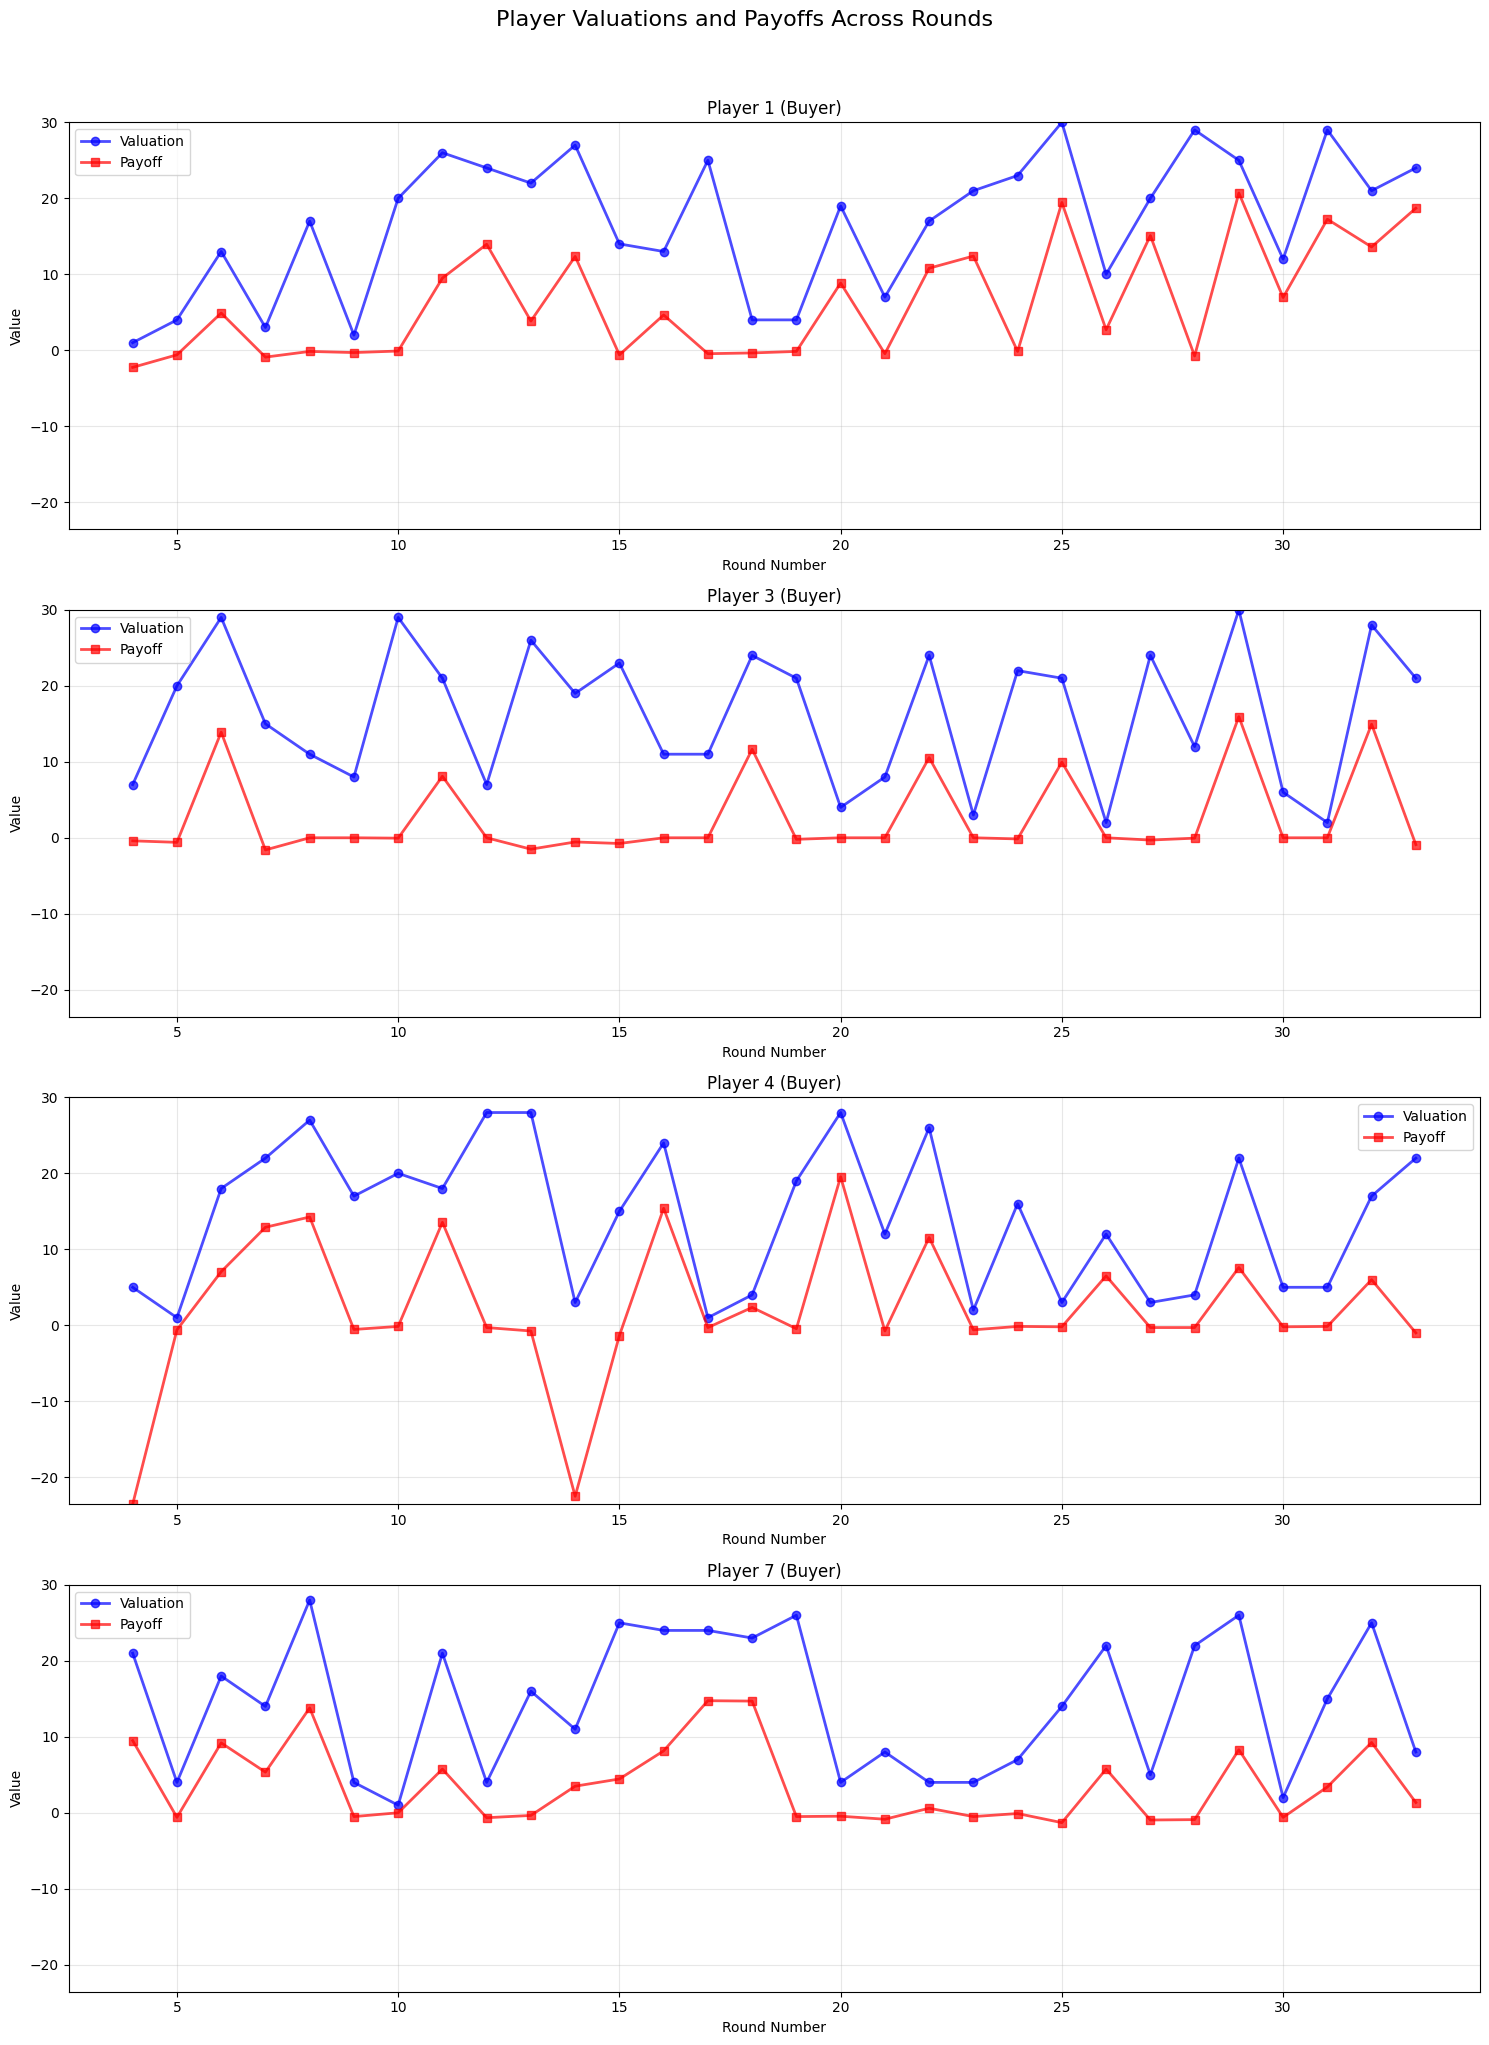

In [18]:
# Create figure with subplots in a 4x2 grid
fig, axes = plt.subplots(4, 1, figsize=(15, 20))
axes = axes.flatten()  # Flatten to make iteration easier

# Get non-zero players from round 7 (as reference)
non_zero_players = data.index[data['bargain_live.7.player.valuation'] > 0]

# Determine global y-axis limits
all_valuations = []
all_payoffs = []
for player in non_zero_players:
    for round_num in range(4, 34):
        all_valuations.append(data.loc[player, f'bargain_live.{round_num}.player.valuation'])
        all_payoffs.append(data.loc[player, f'bargain_live.{round_num}.player.payoff'])

y_min = min(min(all_valuations), min(all_payoffs))
y_max = max(max(all_valuations), max(all_payoffs))

# For each player with non-zero valuations
for idx, player in enumerate(non_zero_players):
    # Get player's role
    player_role = data.loc[player, 'participant.role_in_game']
    
    # Get valuations and payoffs across rounds
    valuations = []
    payoffs = []
    for round_num in range(4, 34):
        val = data.loc[player, f'bargain_live.{round_num}.player.valuation']
        pay = data.loc[player, f'bargain_live.{round_num}.player.payoff']
        valuations.append(val)
        payoffs.append(pay)
    
    # Plot on corresponding subplot
    axes[idx].plot(range(4, 34), valuations, 
                  color='blue', linewidth=2, marker='o', 
                  label='Valuation', alpha=0.7)
    axes[idx].plot(range(4, 34), payoffs, 
                  color='red', linewidth=2, marker='s', 
                  label='Payoff', alpha=0.7)
    
    # Configure subplot
    axes[idx].set_xlabel('Round Number')
    axes[idx].set_ylabel('Value')
    axes[idx].set_title(f'Player {player} ({player_role})')
    axes[idx].set_ylim(y_min, y_max)  # Set consistent y-axis limits
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

# Add main title
fig.suptitle('Player Valuations and Payoffs Across Rounds', fontsize=16, y=1.02)

# Adjust layout
plt.tight_layout()
plt.show()

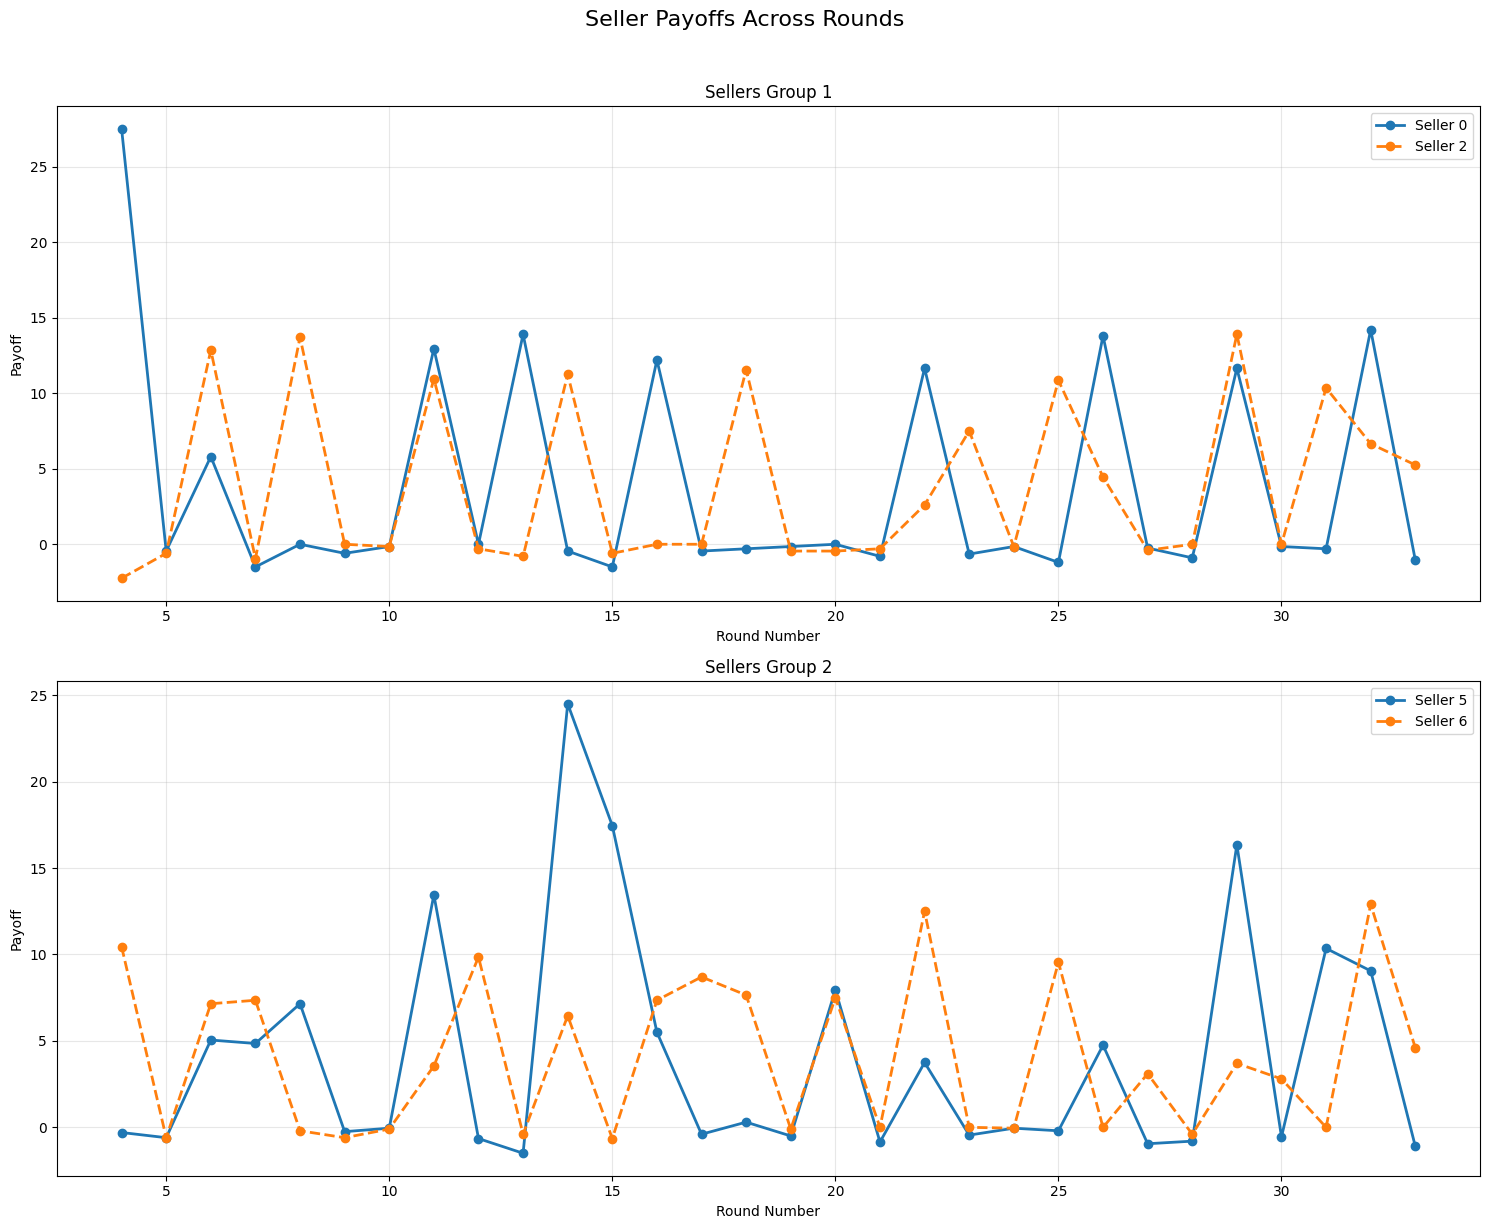

In [19]:


# Create figure with subplots in a 2x2 grid (4 plots for 8 sellers)
fig, axes = plt.subplots(2, 1, figsize=(15, 12))
axes = axes.flatten()  # Flatten to make iteration easier

# Get all sellers
sellers = data[data['participant.role_in_game'] == 'Seller'].index

# Styles for each seller in a subplot
styles = [
    {'color': '#1f77b4', 'linestyle': '-', 'linewidth': 2},    # Solid blue
    {'color': '#ff7f0e', 'linestyle': '--', 'linewidth': 2},   # Dashed orange
]

# For each subplot (pair of sellers)
for plot_idx in range(2):
    # Get the two sellers for this subplot
    seller1 = sellers[plot_idx * 2]
    seller2 = sellers[plot_idx * 2 + 1]
    
    # Get payoffs for both sellers
    for idx, seller in enumerate([seller1, seller2]):
        payoffs = []
        for round_num in range(4, 34):
            pay = data.loc[seller, f'bargain_live.{round_num}.player.payoff']
            payoffs.append(pay)
        
        # Plot with corresponding style
        style = styles[idx]
        axes[plot_idx].plot(range(4, 34), payoffs, 
                          marker='o', markersize=6,
                          label=f'Seller {seller}',
                          **style)
    
    # Configure subplot
    axes[plot_idx].set_xlabel('Round Number')
    axes[plot_idx].set_ylabel('Payoff')
    axes[plot_idx].set_title(f'Sellers Group {plot_idx + 1}')
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].legend()

# Add main title
fig.suptitle('Seller Payoffs Across Rounds', fontsize=16, y=1.02)

# Adjust layout
plt.tight_layout()
plt.show()

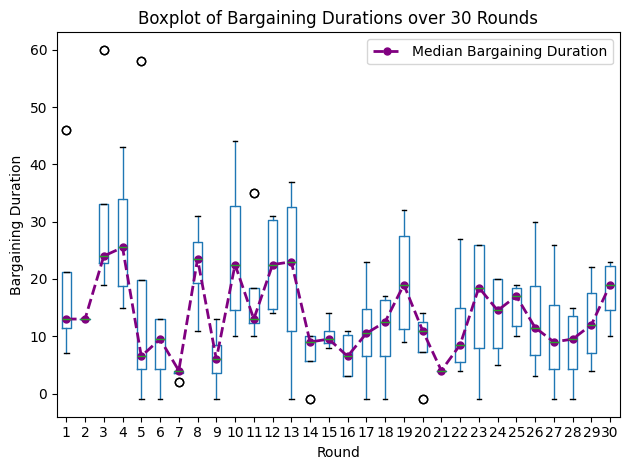

In [20]:
# Extract all bargaining_duration columns for the 29 rounds
bargaining_duration_columns = [f'bargain_live.{i}.group.bargaining_duration' for i in range(4, 34)]

# Filter the relevant data (bargaining durations for 29 rounds)
bargaining_durations = data[bargaining_duration_columns]

# Replace NaN values with 0 (if necessary)
bargaining_durations = bargaining_durations.fillna(0)

bargaining_durations[bargaining_durations > 100] = np.nan

# Create a boxplot for each round
boxplot_bargaining_duration = bargaining_durations.boxplot(column=bargaining_duration_columns, grid=False)

# Draw a line through the medians
medians_bargaining_duration = bargaining_durations.median()
plt.plot(range(1, 31), medians_bargaining_duration, color='purple', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Bargaining Duration')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Bargaining Duration')
plt.title('Boxplot of Bargaining Durations over 30 Rounds')

# Set x-axis labels to number from 1 to 29
boxplot_bargaining_duration.set_xticklabels(range(1, 31))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

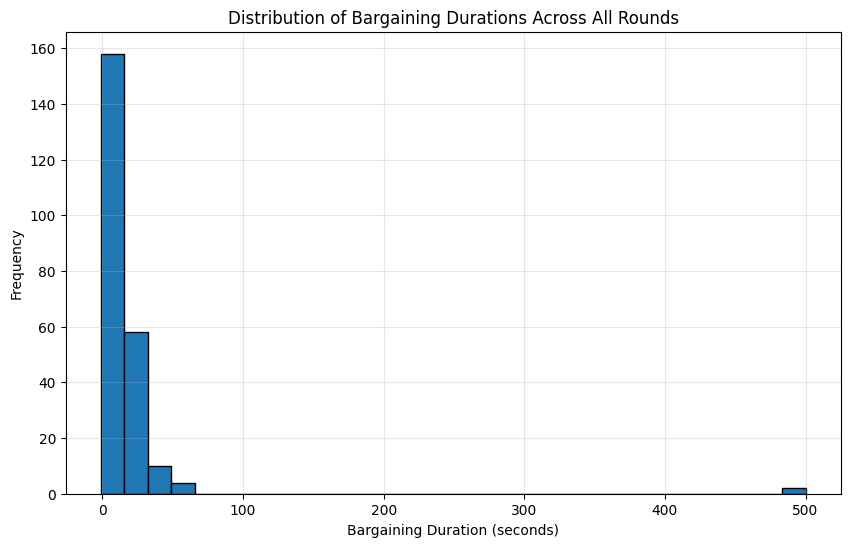

In [21]:
# Extract all bargaining durations into a single series
all_durations = []
for i in range(4, 33):
    durations = data[f'bargain_live.{i}.group.bargaining_duration'].dropna()
    all_durations.extend(durations)

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(all_durations, bins=30, edgecolor='black')
plt.xlabel('Bargaining Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Bargaining Durations Across All Rounds')
plt.grid(True, alpha=0.3)
plt.show()

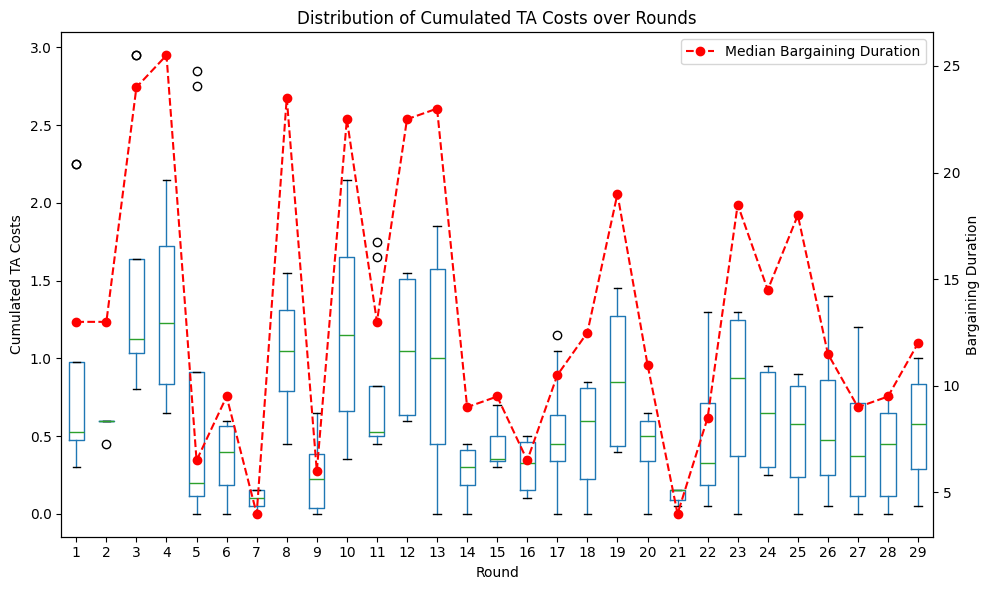

In [22]:
# Extract all cumulated_TA_costs columns for the 20 rounds
cumulated_TA_costs_columns = [f'bargain_live.{i}.player.cumulated_TA_costs' for i in range(4, 33)]

# Filter the relevant data (cumulated TA costs for 20 rounds)
cumulated_TA_costs = data[cumulated_TA_costs_columns]

# Drop NA values
cumulated_TA_costs = cumulated_TA_costs.dropna()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot boxplot on primary axis
cumulated_TA_costs.boxplot(column=cumulated_TA_costs_columns, grid=False, ax=ax1)

# Calculate median bargaining duration for each round
bargaining_duration_columns = [f'bargain_live.{i}.group.bargaining_duration' for i in range(4, 33)]
bargaining_durations = data[bargaining_duration_columns]
median_durations = bargaining_durations.median()

# Create secondary axis
ax2 = ax1.twinx()

# Plot median bargaining duration line on secondary axis
ax2.plot(range(1, 30), median_durations, color='red', marker='o', linestyle='--', label='Median Bargaining Duration')

# Set labels and title
ax1.set_xlabel('Round')
ax1.set_ylabel('Cumulated TA Costs')
ax2.set_ylabel('Bargaining Duration')
plt.title('Distribution of Cumulated TA Costs over Rounds')

# Set x-axis labels to number from 1 to 29
ax1.set_xticks(range(1, 30))
ax1.set_xticklabels(range(1, 30))

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)

# Show the plot
plt.tight_layout()
plt.show()

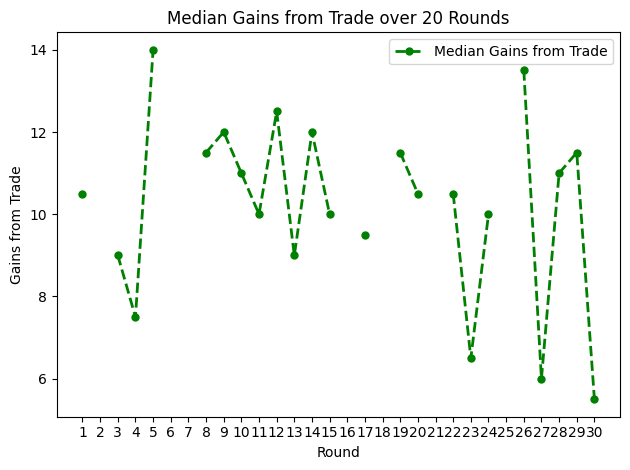

In [23]:
# Calculate gains from trade for each round
gains_from_trade = []
for i in range(4, 34):
    buyer_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.player.valuation'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.group.deal_price']
    seller_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.group.deal_price'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.player.valuation']
    gains_from_trade.append(pd.concat([buyer_gains, seller_gains]))

# Concatenate all rounds and calculate median gains from trade
gains_from_trade_df = pd.concat(gains_from_trade, axis=1)
medians_gains_from_trade = gains_from_trade_df.median(axis=0)

# Plot the median gains from trade
plt.plot(range(1, 31), medians_gains_from_trade, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Gains from Trade')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Gains from Trade')
plt.title('Median Gains from Trade over 20 Rounds')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 31))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

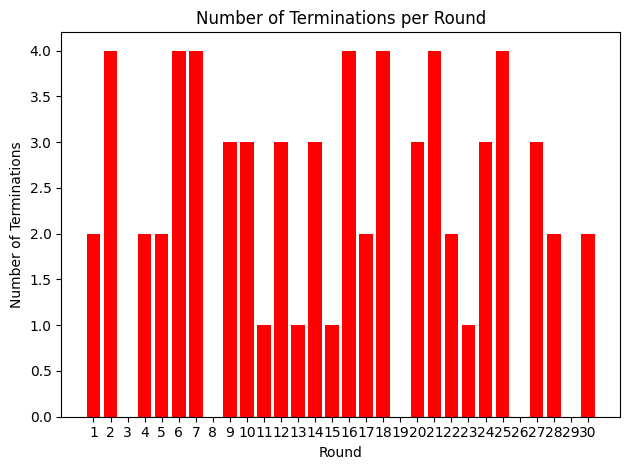

In [24]:
# Extract all terminated columns for the 20 rounds
terminated_columns = [f'bargain_live.{i}.group.terminated' for i in range(4, 34)]

# Filter the relevant data (termination status for 20 rounds)
terminated_data = data[terminated_columns]

# Count the number of terminations per round and divide by 2
terminations_per_round = terminated_data.sum() / 2

# Create a bar plot for terminations per round
plt.bar(range(1, 31), terminations_per_round, color='red')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Number of Terminations')
plt.title('Number of Terminations per Round')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 31))

# Show the plot
plt.tight_layout()
plt.show()

# Who makes the first offer? Buyer or Seller

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
import pdb

In [26]:


# Assume your DataFrame is named df
# Define the rounds of interest
rounds = range(4, 33)  # rounds 4 to 33 inclusive
buyer_first_counts = []

# Define a helper function to parse the offer_time_list string and return the first offer time
def get_first_offer_time(offer_str):
    try:
        # Convert the string representation of a list to an actual list
        offer_list = ast.literal_eval(offer_str)
        return offer_list[0]  # the first offer time
    except Exception:
        return np.nan

# Loop through each round
for round_num in rounds:
    # Construct column names dynamically
    group_col = f"bargain_live.{round_num}.group.id_in_subsession"
    offer_time_col = f"bargain_live.{round_num}.player.offer_time_list"
    role_col = f"bargain_live.{round_num}.player.role"
    
    # Create a temporary column that extracts the first offer time from the offer_time_list string
    data['first_offer'] = data[offer_time_col].apply(get_first_offer_time)
    
    # Initialize count for the current round
    count = 0
    
    # Group by the pair identifier (each pair is in the same group)
    for group_id, group in data.groupby(group_col):
        # Find the index of the row with the earliest (minimum) first offer time in the group
        min_idx = group['first_offer'].idxmin()
        # Check if the role of that row is 'Buyer'
        if min_idx is not None and pd.notna(min_idx):
            if group.loc[min_idx, role_col] == 'Buyer':
                count += 1
     
            
    # Append the count for the current round
    buyer_first_counts.append(count)



/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_97056/2181168192.py:31: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  min_idx = group['first_offer'].idxmin()
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_97056/2181168192.py:31: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  min_idx = group['first_offer'].idxmin()
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_97056/2181168192.py:31: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  min_idx = group['first_offer'].idxmin()
/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_97056/2181168192.py:31: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA an

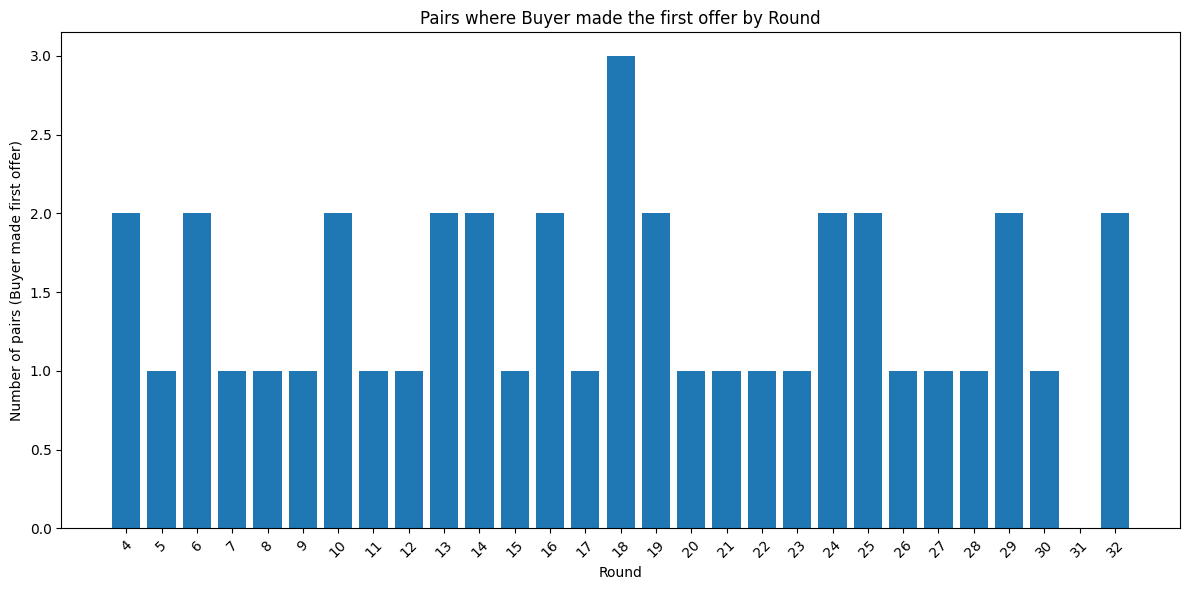

In [27]:
# Create a bar plot for the counts per round
plt.figure(figsize=(12, 6))
plt.bar([str(r) for r in rounds], buyer_first_counts)
plt.xlabel('Round')
plt.ylabel('Number of pairs (Buyer made first offer)')
plt.title('Pairs where Buyer made the first offer by Round')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## How is the first offer set? 

In [28]:
# Initialize lists to store the results
first_offer_ratios = []
round_numbers = []

# Loop through rounds 4 to 33
for round_num in range(4, 34):
    # Get the relevant columns
    offers_col = f'bargain_live.{round_num}.player.amount_proposed_list'
    offer_time_col = f'bargain_live.{round_num}.player.offer_time_list'
    valuation_col = f'bargain_live.{round_num}.player.valuation'
    role_col = f'bargain_live.{round_num}.player.role'
    group_col = f'bargain_live.{round_num}.group.id_in_subsession'
    
    # Get data for this round
    round_data = data[[offers_col, offer_time_col, valuation_col, role_col, group_col]].copy()
    
    # Process each group (pair) separately
    for group_id, group in round_data.groupby(group_col):
        # Find who made the first offer in this group
        first_offer_times = []
        for idx, row in group.iterrows():
            try:
                times = ast.literal_eval(row[offer_time_col])
                if times:  # If there are any offers
                    first_offer_times.append((idx, times[0]))
            except (ValueError, TypeError, SyntaxError):
                continue
        
        if first_offer_times:
            # Find the player who made the first offer
            first_offer_idx = min(first_offer_times, key=lambda x: x[1])[0]
            
            # If the first offer was made by a buyer
            if group.loc[first_offer_idx, role_col] == 'Buyer':
                try:
                    # Get the first offer amount
                    offers = ast.literal_eval(group.loc[first_offer_idx, offers_col])
                    if offers:  # If there are any offers
                        first_offer = offers[0]
                        valuation = group.loc[first_offer_idx, valuation_col]
                        if valuation > 0:  # Avoid division by zero
                            ratio = first_offer / valuation
                            first_offer_ratios.append(ratio)
                            round_numbers.append(round_num)
                except (ValueError, TypeError, SyntaxError):
                    continue

# Create a DataFrame with the results
results_df = pd.DataFrame({
    'Round': round_numbers,
    'First_Offer_Ratio': first_offer_ratios
})


Total number of first offers analyzed: 43
Average ratio of first offer to valuation: 0.26
Median ratio of first offer to valuation: 0.21


<Figure size 1200x600 with 0 Axes>

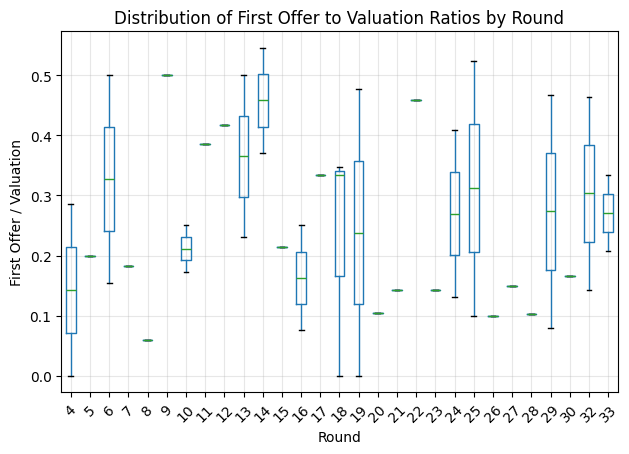

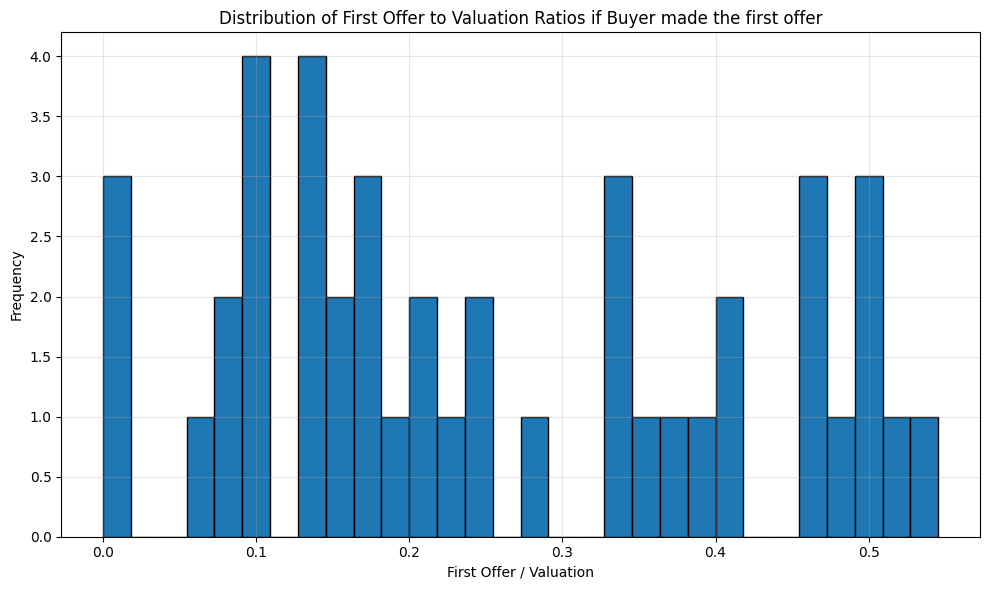

In [29]:

# Calculate statistics
print(f"Total number of first offers analyzed: {len(first_offer_ratios)}")
print(f"Average ratio of first offer to valuation: {np.mean(first_offer_ratios):.2f}")
print(f"Median ratio of first offer to valuation: {np.median(first_offer_ratios):.2f}")

# Create boxplot
plt.figure(figsize=(12, 6))
results_df.boxplot(column='First_Offer_Ratio', by='Round')
plt.title('Distribution of First Offer to Valuation Ratios by Round')
plt.suptitle('')  # Remove default title
plt.xlabel('Round')
plt.ylabel('First Offer / Valuation')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create histogram of all ratios
plt.figure(figsize=(10, 6))
plt.hist(first_offer_ratios, bins=30, edgecolor='black')
plt.title('Distribution of First Offer to Valuation Ratios if Buyer made the first offer')
plt.xlabel('First Offer / Valuation')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Now, lets see what sellers do

In [30]:
import pdb

In [31]:
# Initialize lists to store the results
first_offer_ratios = []
round_numbers = []

# Loop through rounds 4 to 33
for round_num in range(4, 34):
    # Get the relevant columns
    offers_col = f'bargain_live.{round_num}.player.amount_proposed_list'
    offer_time_col = f'bargain_live.{round_num}.player.offer_time_list'
    valuation_col = f'bargain_live.{round_num}.player.valuation'
    role_col = f'bargain_live.{round_num}.player.role'
    group_col = f'bargain_live.{round_num}.group.id_in_subsession'
    
    # Get data for this round
    round_data = data[[offers_col, offer_time_col, valuation_col, role_col, group_col]].copy()
    
    # Process each group (pair) separately
    for group_id, group in round_data.groupby(group_col):
        
        # Find who made the first offer in this group
        first_offer_times = []
        for idx, row in group.iterrows():
            try:
                times = ast.literal_eval(row[offer_time_col])
                if times:  # If there are any offers
                    first_offer_times.append((idx, times[0]))
            except (ValueError, TypeError, SyntaxError):
                continue
        
        if first_offer_times:
            # Find the player who made the first offer
            first_offer_idx = min(first_offer_times, key=lambda x: x[1])[0]
            
            # If the first offer was made by a buyer
            if group.loc[first_offer_idx, role_col] == 'Seller':

                try:
                    # Get the first offer amount
                    offers = ast.literal_eval(group.loc[first_offer_idx, offers_col])
                    if offers:  # If there are any offers
                        first_offer = offers[0]
                        first_offer_ratios.append(first_offer)
                        round_numbers.append(round_num)
                except (ValueError, TypeError, SyntaxError):
                    continue

# Create a DataFrame with the results
results_df = pd.DataFrame({
    'Round': round_numbers,
    'First_Offer_Ratio': first_offer_ratios
})


In [32]:
results_df

,Round,First_Offer_Ratio
0,4,21.0
1,4,28.0
2,5,23.0
3,5,25.0
4,5,29.0
...,...,...
59,31,21.0
60,32,29.0
61,32,27.0
62,33,19.0


Total number of first offers analyzed: 64
Average ratio of first offer to valuation: 25.02
Median ratio of first offer to valuation: 27.00


<Figure size 1200x600 with 0 Axes>

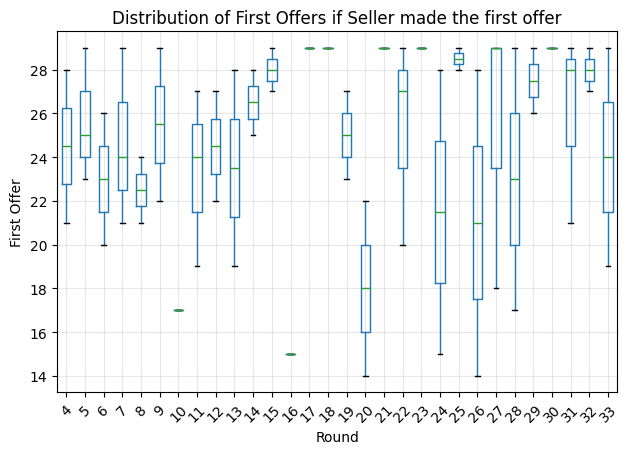

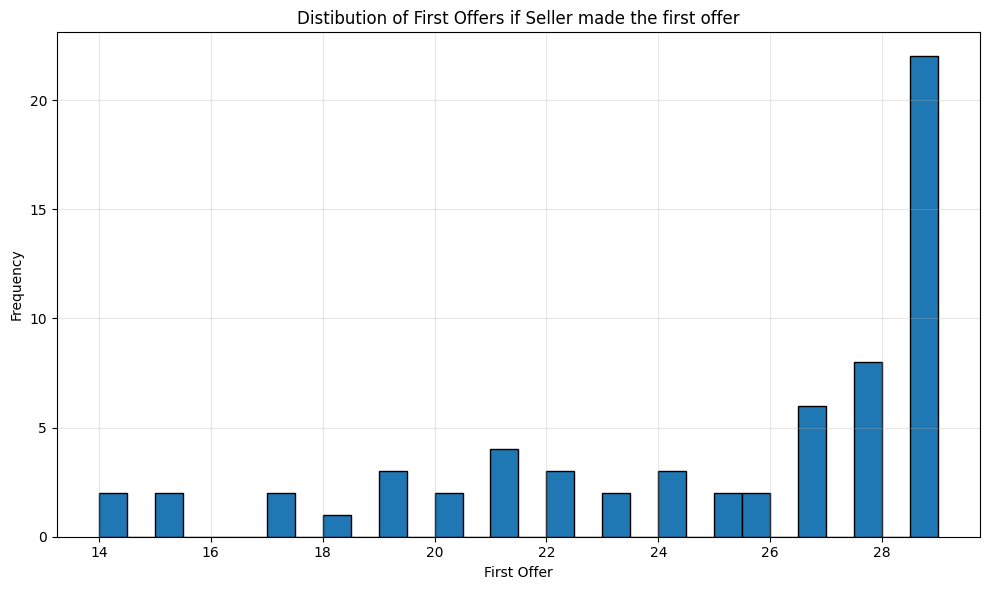

In [33]:

# Calculate statistics
print(f"Total number of first offers analyzed: {len(first_offer_ratios)}")
print(f"Average ratio of first offer to valuation: {np.mean(first_offer_ratios):.2f}")
print(f"Median ratio of first offer to valuation: {np.median(first_offer_ratios):.2f}")

# Create boxplot
plt.figure(figsize=(12, 6))
results_df.boxplot(column='First_Offer_Ratio', by='Round')
plt.title('Distribution of First Offers if Seller made the first offer')
plt.suptitle('')  # Remove default title
plt.xlabel('Round')
plt.ylabel('First Offer')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create histogram of all ratios
plt.figure(figsize=(10, 6))
plt.hist(first_offer_ratios, bins=30, edgecolor='black')
plt.title('Distibution of First Offers if Seller made the first offer')
plt.xlabel('First Offer')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# Initialize counter for accepted seller first offers
accepted_seller_first_offers = 0
total_seller_first_offers = 0

# Loop through rounds 4 to 33
for round_num in range(4, 34):
    # Get the relevant columns
    offers_col = f'bargain_live.{round_num}.player.amount_proposed_list'
    offer_time_col = f'bargain_live.{round_num}.player.offer_time_list'
    role_col = f'bargain_live.{round_num}.player.role'
    group_col = f'bargain_live.{round_num}.group.id_in_subsession'
    termination_mode_col = f'bargain_live.{round_num}.group.termination_mode'
    
    # Get data for this round
    round_data = data[[offers_col, offer_time_col, role_col, group_col, termination_mode_col]].copy()
    
    # Process each group (pair) separately
    for group_id, group in round_data.groupby(group_col):
        # Find who made the first offer in this group
        first_offer_times = []
        for idx, row in group.iterrows():
            try:
                times = ast.literal_eval(row[offer_time_col])
                if times:  # If there are any offers
                    first_offer_times.append((idx, times[0]))
            except (ValueError, TypeError, SyntaxError):
                continue
        
        if first_offer_times:
            # Find the player who made the first offer
            first_offer_idx = min(first_offer_times, key=lambda x: x[1])[0]
            
            # If the first offer was made by a seller
            if group.loc[first_offer_idx, role_col] == 'Seller':
                total_seller_first_offers += 1
                
                # Get the buyer's index
                buyer_idx = group[group[role_col] == 'Buyer'].index[0]
                
                # Check if buyer's offer list is empty
                try:
                    buyer_offers = ast.literal_eval(group.loc[buyer_idx, offers_col])
                    # Check if termination mode is "Player" and buyer made no offers
                    if (group.loc[first_offer_idx, termination_mode_col] == "Player" and 
                        (not buyer_offers or len(buyer_offers) == 0)):
                        accepted_seller_first_offers += 1
                except (ValueError, TypeError, SyntaxError):
                    continue

# Print results
print(f"Total number of times seller made first offer: {total_seller_first_offers}")
print(f"Number of times seller's first offer was accepted: {accepted_seller_first_offers}")
print(f"Acceptance rate of seller's first offers: {(accepted_seller_first_offers/total_seller_first_offers)*100:.2f}%")

Total number of times seller made first offer: 64
Number of times seller's first offer was accepted: 2
Acceptance rate of seller's first offers: 3.12%


## Number of offers per round

In [34]:
for i in range(4, 33):
    data[f"Round_{i}_offers"] = data[f"bargain_live.{i}.player.offer_time_list"].apply(lambda x: len(ast.literal_eval(x)))


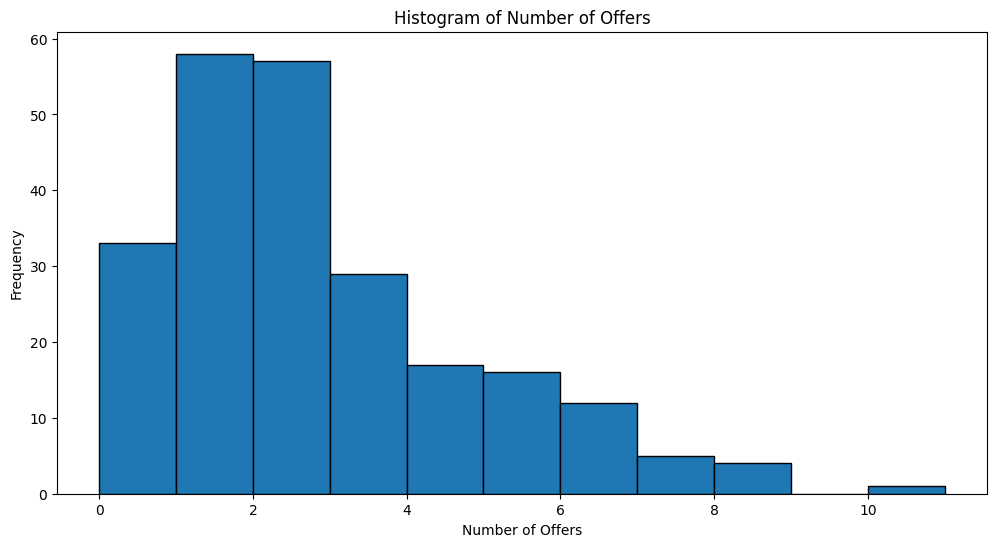

In [35]:
all_offers = data[[f"Round_{i}_offers" for i in range(4, 33)]].values.flatten()
plt.figure(figsize=(12, 6))
plt.hist(all_offers, bins=range(int(all_offers.min()), int(all_offers.max()) + 2), edgecolor='black')
plt.xlabel('Number of Offers')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Offers')
plt.show()